# Exploratory Data Analysis — `honeywell_gold_dataset.csv`

## Kontekst problemu

**Atak GPS Spoofing** to klasa ataków cyber-fizycznych, w której atakujący nadaje sfałszowany sygnał GNSS, sprawiając że odbiornik ofiary obliczy błędną pozycję, prędkość lub czas. Dla drona atak może:

* **przesunąć raportowaną pozycję poziomą** poza prawdziwą trajektorię (`horizontal_drift`),
* **zafałszować raportowaną wysokość** zachowując wiarygodną pozycję poziomą (`altitude_spoof`),
* **wstrzyknąć syntetyczną kołową trajektorię** całkowicie oderwaną od rzeczywistego ruchu (`circular_spoof`).

Autopilot fuzjonuje GPS z IMU/barometrem w Extended Kalman Filter (EKF). Estymata fuzyjna (`vehicle_global_position`, `vehicle_local_position`) i surowy GPS (`vehicle_gps_position`) są raportowane oddzielnie — rozbieżność między nimi jest jednym z najsilniejszych fizycznych wskaźników, że źródło GPS zostało skompromitowane.

## Cele tego notebooka

1. Potwierdzić strukturę datasetu, kompletność i balans klas.
2. Zwizualizować każdy scenariusz spoofingu bezpośrednio: pokazać jak atak manifestuje się w surowych sygnałach.
3. Skwantyfikować separowalność między próbkami normalnymi a anomalnymi na cechach kandydujących.
4. Uzasadnić, dlaczego ten dataset nadaje się do trenowania detektora spoofingu.

## Dlaczego ten dataset

* **Realna telemetria PX4** (`vehicle_attitude`, `vehicle_global_position`, `vehicle_gps_position`, `vehicle_local_position`) — nie syntetyczny szum. Cechy mają fizyczne znaczenie.
* **Obie klasy obecne** — `clean_flight` (brak ataku) plus trzy odrębne klasy ataków.
* **Wiele realistycznych scenariuszy spoofingu** pokrywających ataki tylko-poziome, tylko-pionowe i wstrzyknięcia trajektorii.
* **Zbalansowana liczba próbek** między scenariuszami (6 248 wierszy każdy → łącznie 24 992).
* **Współwystępowanie estymaty EKF i surowego GPS** — rozbieżność między nimi to dobrze umotywowany, fizycznie uzasadniony wskaźnik spoofingu używalny jako cecha.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


In [14]:
df = pd.read_csv('honeywell_gold_dataset.csv')
print('shape:', df.shape)
print('kolumny:', len(df.columns))
print('komorki null:', int(df.isnull().sum().sum()))
print('duplikaty :', int(df.duplicated().sum()))
df.head()


shape: (24992, 84)
kolumny: 84
komorki null: 0
duplikaty : 0


,timestamp,q[0],q[1],q[2],q[3],delta_q_reset[0],delta_q_reset[1],delta_q_reset[2],delta_q_reset[3],quat_reset_counter,...,v_z_valid,xy_reset_counter,z_reset_counter,vxy_reset_counter,vz_reset_counter,heading_reset_counter,xy_global,z_global,dist_bottom_valid,label
0,0,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,0
1,1,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,0
2,2,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,0
3,3,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,0
4,4,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,0


## Rozkład klas

Dataset ułożony jest w cztery sklejone bloki scenariuszy. Każdy blok ma 6 248 wierszy; scenariusze ataków zawierają czysty preambuł zanim rozpocznie się okno spoofingu.

In [15]:
# Rozkład etykiety label
print(df['label'].value_counts())
print(f'\nUdział label=1: {df["label"].mean():.3f}')


label
1    13122
0    11870
Name: count, dtype: int64

Udział label=1: 0.525


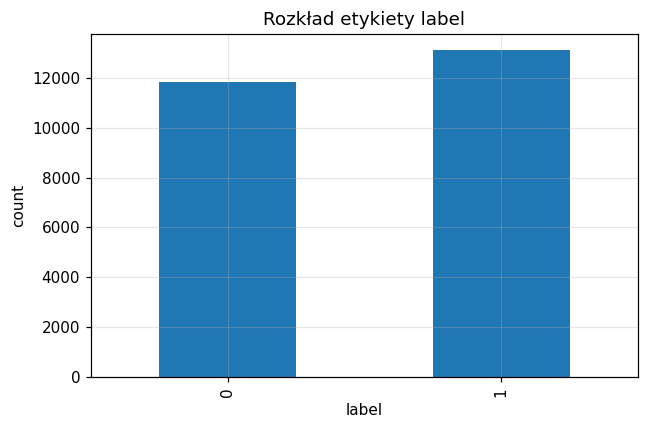

In [16]:
# Prosty wykres rozkładu label
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
df['label'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_xlabel('label')
ax.set_ylabel('count')
ax.set_title('Rozkład etykiety label')
plt.tight_layout()
plt.show()


## Jakość danych

* Brak nulli, brak duplikatów.
* `timestamp` to indeks próbki (`0..6247` w każdym bloku, krok 1) — nie czas rzeczywisty. `time_utc_usec`, `timestamp_time_relative` są stałe-zero w tym pliku, więc nie ma absolutnej referencji czasowej.
* **35 z 85 kolumn jest stałych** (głównie liczniki resetów EKF, flagi walidacji, origin lokalnego frame'u). Nie niosą informacji i powinny być usunięte przed modelowaniem.
* **Niezgodność jednostek między EKF (`*_x`) a surowym GPS (`*_y`)**: `lat_y, lon_y` są w stopniach × 1e7 (raw sensor format), `alt_y` w milimetrach. Trzeba przeskalować przed bezpośrednim porównaniem.

In [17]:
const_cols = sorted([c for c in df.columns if df[c].nunique() == 1])
print(f'Stale kolumny: {len(const_cols)}')
print(const_cols)


Stale kolumny: 35
['alt_reset_counter', 'dead_reckoning', 'delta_alt', 'delta_heading', 'delta_q_reset[0]', 'delta_q_reset[1]', 'delta_q_reset[2]', 'delta_q_reset[3]', 'delta_vxy[0]', 'delta_vxy[1]', 'delta_vz', 'delta_xy[0]', 'delta_xy[1]', 'delta_z', 'fix_type', 'heading_offset', 'heading_reset_counter', 'lat_lon_reset_counter', 'quat_reset_counter', 'ref_alt', 'ref_lat', 'ref_lon', 'time_utc_usec', 'timestamp_time_relative', 'v_xy_valid', 'v_z_valid', 'vel_ned_valid', 'vxy_reset_counter', 'vz_reset_counter', 'xy_global', 'xy_reset_counter', 'xy_valid', 'z_global', 'z_reset_counter', 'z_valid']


### Normalizacja jednostek

In [18]:
data = df.copy()
data['lat_y']           = data['lat_y'] / 1e7
data['lon_y']           = data['lon_y'] / 1e7
data['alt_y']           = data['alt_y'] / 1000.0
data['alt_ellipsoid_y'] = data['alt_ellipsoid_y'] / 1000.0

cmp = pd.DataFrame({
    'lat_x (EKF, deg)' : data['lat_x'].head(3).values,
    'lat_y (GPS, deg)' : data['lat_y'].head(3).values,
    'alt_x (EKF, m)'   : data['alt_x'].head(3).values,
    'alt_y (GPS, m)'   : data['alt_y'].head(3).values,
})
cmp


,"lat_x (EKF, deg)","lat_y (GPS, deg)","alt_x (EKF, m)","alt_y (GPS, m)"
0,36.204812,36.204812,51.336754,49.2040
1,36.204812,36.204812,51.336754,49.2040
2,36.204812,36.204812,51.336754,49.2006


## Wizualna historia każdego ataku

Dla każdego scenariusza rysujemy estymatę EKF przeciwko surowemu GPS w odpowiedniej osi. W `clean_flight` te dwa powinny się zgadzać — każda utrzymująca się luka to to, co spoofing wprowadza.

* `horizontal_drift` — wolno rosnąca rozbieżność pozioma po onsetcie ataku (~wiersz 1 874 w bloku).
* `altitude_spoof` — rozbieżność tylko pionowa (alt_x vs alt_y) zaczynająca się około wiersza 2 499.
* `circular_spoof` — duże, oscylujące przesunięcie poziome zaczynające się około wiersza 1 249.

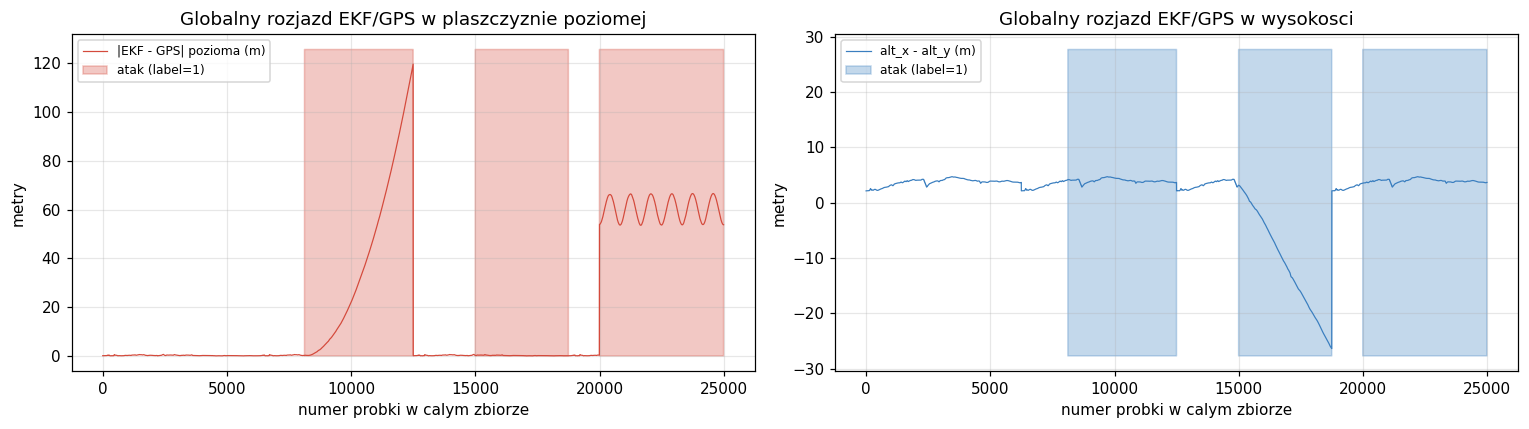

In [19]:
def add_divergence(d):
    d = d.copy()
    cos_lat = np.cos(np.radians(d['lat_x']))
    d['lat_diff_m']   = (d['lat_x'] - d['lat_y']) * 111_000.0
    d['lon_diff_m']   = (d['lon_x'] - d['lon_y']) * 111_000.0 * cos_lat
    d['alt_diff_m']   =  d['alt_x'] - d['alt_y']
    d['pos_diff_h_m'] = np.sqrt(d['lat_diff_m']**2 + d['lon_diff_m']**2)
    return d

data = add_divergence(data)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=False)

idx = data.index.values
label_pos = data['label'].values

# Rozjazd poziomy
ax = axes[0]
ax.plot(idx, data['pos_diff_h_m'], color='#d44a3c', lw=0.8,
        label='|EKF - GPS| pozioma (m)')
ymax_h = data['pos_diff_h_m'].max()*1.05 if data['pos_diff_h_m'].max() > 0 else 1
ax.fill_between(idx, 0, ymax_h,
                where=(label_pos == 1), color='#d44a3c', alpha=0.30,
                label='atak (label=1)')
ax.set_title('Globalny rozjazd EKF/GPS w plaszczyznie poziomej')
ax.set_ylabel('metry')
ax.legend(loc='upper left', fontsize=8)

# Rozjazd pionowy
ax = axes[1]
ax.plot(idx, data['alt_diff_m'], color='#3a7ebf', lw=0.8,
        label='alt_x - alt_y (m)')
yspan = max(abs(data['alt_diff_m'].min()), abs(data['alt_diff_m'].max()))
ax.fill_between(idx, -yspan*1.05, yspan*1.05,
                where=(label_pos == 1), color='#3a7ebf', alpha=0.30,
                label='atak (label=1)')
ax.set_title('Globalny rozjazd EKF/GPS w wysokosci')
ax.set_ylabel('metry')
ax.legend(loc='upper left', fontsize=8)

axes[0].set_xlabel('numer probki w calym zbiorze')
axes[1].set_xlabel('numer probki w calym zbiorze')
plt.tight_layout()
plt.show()


## Widok trajektorii 2D

Pozycja EKF w lokalnym układzie NED (`x = na pólnoc, y = na wschód`) dla każdego scenariusza, oznaczona kolorem wg etykiety. Każdy scenariusz startuje blisko origin; scenariusze spoofingu przesuwają *raportowaną* trajektorię poza prawdziwą.

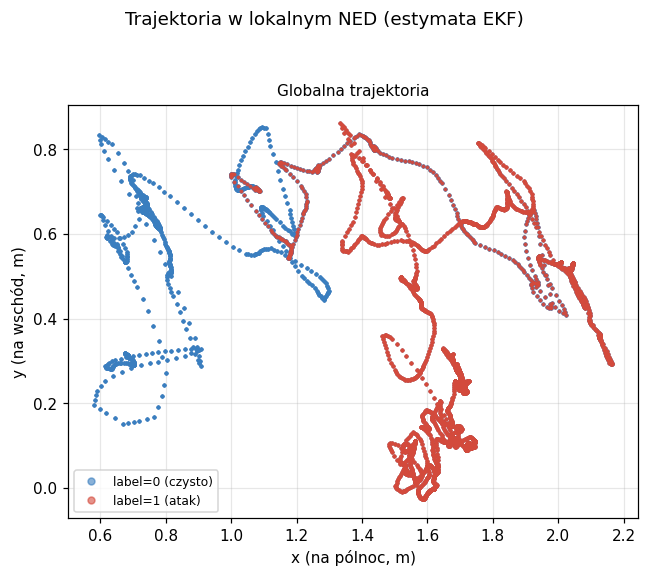

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

clean = data[data['label'] == 0]
spoof = data[data['label'] == 1]
ax.plot(clean['x'], clean['y'], 'o', ms=1.5, color='#3a7ebf', alpha=0.6, label='label=0 (czysto)')
ax.plot(spoof['x'], spoof['y'], 'o', ms=1.5, color='#d44a3c', alpha=0.6, label='label=1 (atak)')
ax.set_title('Globalna trajektoria', fontsize=10)
ax.set_xlabel('x (na pólnoc, m)')
ax.set_ylabel('y (na wschód, m)')
ax.legend(fontsize=8, markerscale=3)
plt.suptitle('Trajektoria w lokalnym NED (estymata EKF)', y=1.04)
plt.tight_layout()
plt.show()


## Shift dystrybucji: czysty lot vs anomalia

Box ploty kandydujących cech rozjazdu podzielone wg etykiety, tylko na scenariuszach ataków (`clean_flight` wykluczony — nie ma pozytywów). Separacja między dwoma boxami = cecha jest informatywna dla tego scenariusza.

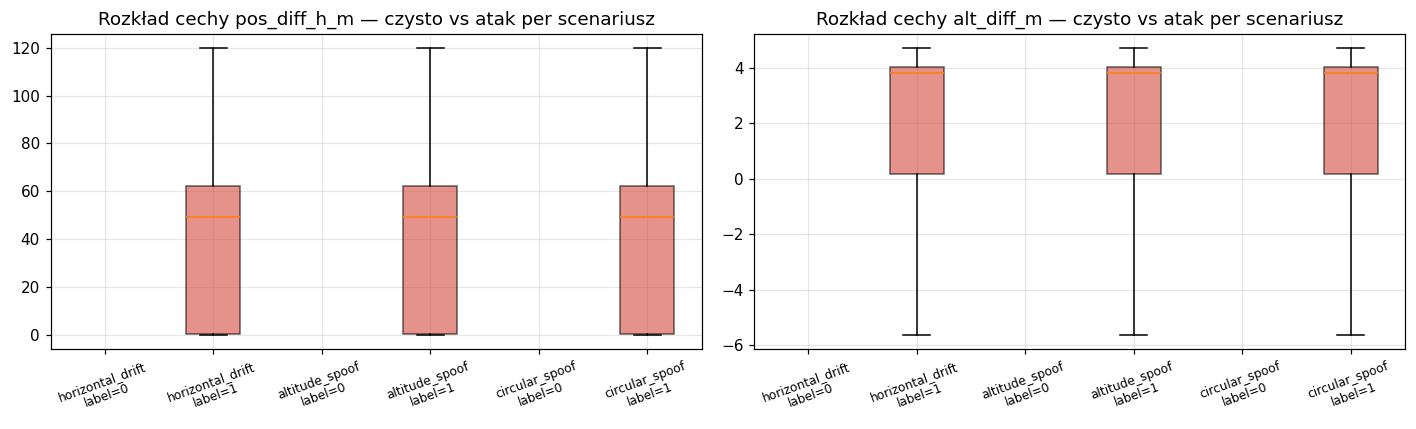

In [21]:
KEY = ['pos_diff_h_m', 'alt_diff_m']

attack = data[data['label'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, feat in zip(axes, KEY):
    boxdata = []
    labels = []
    for s in ['horizontal_drift','altitude_spoof','circular_spoof']:
        sub = data[data['label'] == 1]
        boxdata.append(sub.loc[sub['label']==0, feat].values)
        boxdata.append(sub.loc[sub['label']==1, feat].values)
        labels.append(f'{s}\nlabel=0')
        labels.append(f'{s}\nlabel=1')
    bp = ax.boxplot(boxdata, labels=labels, patch_artist=True, showfliers=False)
    colors = ['#3a7ebf', '#d44a3c'] * 3
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    ax.set_title(f'Rozkład cechy {feat} — czysto vs atak per scenariusz')
    ax.tick_params(axis='x', labelsize=8, rotation=20)
plt.tight_layout()
plt.show()


## Raportowana niepewność GPS *zmienia się* pod spoofingiem

`eph_y` (1σ horyzontalna) i `s_variance_m_s` (wariancja prędkości) raportowane przez odbiornik GPS rosną w trakcie okna spoofingu w dwóch z trzech ataków. Są użytecznymi cechami dopełniającymi wraz z rozjazdami.

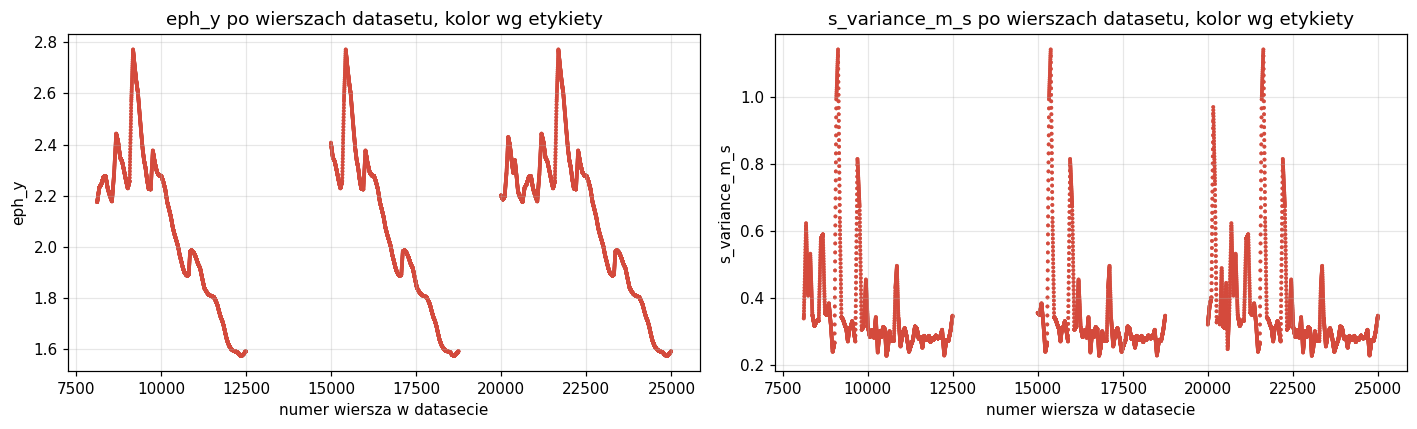

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, feat in zip(axes, ['eph_y', 's_variance_m_s']):
    for s in ['horizontal_drift','altitude_spoof','circular_spoof']:
        sub = data[data['label'] == 1]
        ax.scatter(sub.index, sub[feat], s=2,
                   c=['#3a7ebf' if l==0 else '#d44a3c' for l in sub['label']],
                   label=s, alpha=0.4)
    ax.set_title(f'{feat} po wierszach datasetu, kolor wg etykiety')
    ax.set_xlabel('numer wiersza w datasecie')
    ax.set_ylabel(feat)
plt.tight_layout()
plt.show()


## Statystyki podstawowe cech kandydujących

In [23]:
summary_features = ['pos_diff_h_m', 'alt_diff_m', 'eph_y', 'epv_y',
                    's_variance_m_s', 'c_variance_rad', 'noise_per_ms',
                    'jamming_indicator', 'satellites_used']
data[summary_features].describe(percentiles=[.25,.5,.75]).round(3).T


,count,mean,std,min,25%,50%,75%,max
pos_diff_h_m,24992.0,19.159,29.408,0.003,0.122,0.287,53.772,119.664
alt_diff_m,24992.0,1.445,6.269,-26.344,2.572,3.724,3.996,4.691
eph_y,24992.0,2.087,0.265,1.574,1.924,2.126,2.278,2.772
epv_y,24992.0,2.900,0.276,2.337,2.689,2.962,3.119,3.352
s_variance_m_s,24992.0,0.376,0.150,0.228,0.285,0.321,0.401,1.143
c_variance_rad,24992.0,0.847,0.487,0.642,0.642,0.642,0.642,2.017
noise_per_ms,24992.0,99.911,6.046,90.000,95.000,100.000,105.000,110.000
jamming_indicator,24992.0,40.007,3.162,35.000,37.000,40.000,43.000,45.000
satellites_used,24992.0,11.004,0.818,10.000,10.000,11.000,12.000,12.000


## Podsumowanie

* **Rozmiar**: 24 992 wierszy × 85 kolumn; 0 nulli, 0 duplikatów. Po wyrzuceniu 35 stałych kolumn i indeksu `timestamp`, **47 informatywnych surowych cech zostaje**.
* **Balans klas**: 53% anomalii w pliku (label=1), napędzane przez scenariusze ataków (60%, 70%, 80% pozytywów). `clean_flight` jest w pełni negatywny i dostarcza baseline'u bez ataku.
* **Pokrycie**: trzy odrębne wzorce ataków (drift tylko-poziomy, spoof tylko-pionowy, wstrzyknięcie kołowej trajektorii) plus baseline. Każdy scenariusz zawiera czysty preambuł i okno aktywnego ataku — każdy scenariusz wnosi obie klasy (poza `clean_flight`).
* **Najsilniejszy fizyczny sygnał** dla detekcji spoofingu to **rozjazd EKF vs raw GPS**, widoczny w każdym scenariuszu ataku po onsetcie. Metryki zdrowia odbiornika *nie* są użytecznym tellem.
* **Przydatność do ML**: realna telemetria, multi-scenariuszowe pokrycie, obie klasy dobrze reprezentowane, oczywista fizycznie uzasadniona kandydująca cecha (rozjazd) — sprawdzony jako benchmark detekcji spoofingu.

Dalej: feature engineering i modelowanie w `solution.ipynb`.